# Delay comparison between combined-H5 runs

Counterpart of `vls_compare_runs.ipynb` for fully combined H5 files
(SDU + VLS + GMD already aligned by train ID). Loads N files via
`load_data`, bins shots by delay-stage position (`z`), and produces
the same family of comparisons as the raw-run notebook:

1. Mean spectrum and per-bunch / per-train maps per file.
2. Per-shot spectral moments and COM / width distribution overlays.
3. Delay distribution overlay across files (new — `z` is the scan
   variable here, not a fixed parameter).
4. GMD vs per-shot VLS sum.
5. Average VLS spectrum per GMD bin AND per delay bin.
6. Final comparison: spectra per (delay bin x GMD bin), GMD-normalised
   via `sum(spectra) / sum(GMD)` per cell.
7. Mean `|FFT(spectrum)|` per file.

Differences vs `vls_compare_runs`:

- Loads combined H5 (not raw H5); no background-run subtraction or
  bunch-axis roll because the combined files are already aligned.
- An optional `auto_subtract_background` over a "no-signal" bunch
  range mirrors the per-train baseline removal.
- The COM axis of the final comparison is replaced by the delay
  axis. The original COM-vs-GMD final figure didn't apply here.

In [9]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

import config
from data_loading import load_data, load_raw_h5
from binning import arb_bool_ar, bin_and_average, bin_and_sum_ratio
%matplotlib inline

## Parameters

In [10]:
# Combined H5 files to compare. Add or remove freely; every downstream
# cell loops over `runs` so adding a third file just adds a panel /
# extra line.
FILES = [
    config.COMBINED_DIR / "interferometry_scan_from-15000_to15000_speed100.h5",
]
# Optional human-readable label per file. Falls back to the file stem
# when the list is shorter than FILES.
LABELS = []

# Trim edges on load (matches load_data defaults).
TRIM_START   = 2
TRIM_END     = 2
DOWNSAMPLE_N = 100

# Cyclic shift (np.roll) of the VLS bunch axis applied right after
# load_data. Use this to align the Gotthard line index with the FEL
# bunch index. 0 = no roll.
GOTTHARD_ROLL = -2

# Optional VLS background read from a separate raw FLASH run (shutter
# closed). Set BG_RUN_NO to None to skip this step. BG_MAX_FILES caps
# how many raw H5 files of the background run are read; BG_TRAIN_LENGTH
# is the bunch count to load the bg with (must match the combined H5
# files' bunch axis after the roll).
BG_RUN_NO       = 58819
BG_MAX_FILES    = 20
BG_TRAIN_LENGTH = 110

# Per-train auto-background over a no-signal bunch range, applied
# after the pixel crop. Set to None to disable.
BG_BUNCH_RANGE = (101, 108)


# VLS pixel ROI (half-open) applied before moments. None keeps the
# full pixel axis.
ROI = (550, 650)

# Half-open bunch range kept by `trim_bunches` AFTER the bg subtractions
# above. None = keep every bunch.
BUNCH_TRIM_RANGE = (0,100)

# GMD bin edges (uJ). None -> percentile bins from pooled data.
GMD_EDGES = None
N_GMD_BINS = 5

# Delay (z) bin edges. None -> percentile bins from pooled data.
Z_EDGES = None
N_Z_BINS = 20

# Final-comparison resolution (per GMD bin, lines coloured by z bin).
N_GMD_BINS_FINAL = 3
N_Z_BINS_FINAL   = 30

# Log-stretch the bunch / train maps.
LOG_MAP = False

print(f"files to compare: {len(FILES)}")
for p in FILES:
    print(f"  {p}")


files to compare: 1
  /home/ogalex/glycine2026/glycine26/11022188/processed/combined/interferometry_scan_from-15000_to15000_speed100.h5


## VLS background from a separate raw FLASH run (optional)

Set `BG_RUN_NO` in the params cell to load a closed-shutter run via
`load_raw_h5`, roll its bunch axis the same way as the data, and
average over trains to get a `(n_bunches, n_pixels)` background. The
background is subtracted from each combined-H5 run BEFORE the pixel
crop / auto-background / trim. When `BG_RUN_NO` is None this cell
just sets `vls_bg = None` and the rest of the pipeline skips the
subtraction.

In [11]:
if BG_RUN_NO is None:
    vls_bg = None
    print("BG_RUN_NO is None -> skipping VLS background subtraction.")
else:
    bg_data = (
        load_raw_h5(BG_RUN_NO, config=2,
                    max_files=BG_MAX_FILES,
                    train_length=BG_TRAIN_LENGTH)
        .roll_vls_bunches(GOTTHARD_ROLL)
    )
    vls_bg = np.nanmean(bg_data.vls, axis=0)
    print(f"vls_bg from run {BG_RUN_NO}: shape={vls_bg.shape}, "
          f"range={np.nanmin(vls_bg):.1f} .. {np.nanmax(vls_bg):.1f}")

Loading 4 raw H5 file(s) for run 58819 (config 2).
  reading FLASH2_USER1_main_run58819_file1_20260606T003043.1.h5
  reading FLASH2_USER1_main_run58819_file2_20260606T003134.1.h5
  reading FLASH2_USER1_main_run58819_file3_20260606T003214.1.h5
  reading FLASH2_USER1_main_run58819_file4_20260606T003253.1.h5
Loaded 1155 trains x 110 bunches.
vls_bg from run 58819: shape=(110, 1280), range=1281.5 .. 51913.1


## Load and prepare each file

Same preprocessing for every file: load combined H5 -> optional pixel
crop -> optional per-train baseline -> per-shot spectral moments. The
results live in a `runs` dict keyed by file stem (or your explicit
label), and every downstream cell iterates over it.

In [12]:
def _label_for(i, path):
    if i < len(LABELS) and LABELS[i]:
        return LABELS[i]
    return Path(path).stem


def load_and_prepare(path):
    data = load_data(str(path), config=2,
                     trim_start=TRIM_START, trim_end=TRIM_END,
                     downsample_N=DOWNSAMPLE_N)
    # Align the Gotthard line index with the FEL bunch index.
    data = data.roll_vls_bunches(GOTTHARD_ROLL)
    # Subtract the closed-shutter background (broadcast over trains)
    # before any pixel crop, so vls_bg matches the full pixel axis.
    if vls_bg is not None:
        data = data.subtract_background(vls_bg)
    if ROI is not None:
        data = data.crop_vls(*ROI)
    if BG_BUNCH_RANGE is not None:
        data = data.auto_subtract_background(BG_BUNCH_RANGE)
    if BUNCH_TRIM_RANGE is not None:
        data = data.trim_bunches(*BUNCH_TRIM_RANGE)
    data = data.compute_vls_moments()
    return data


runs = {_label_for(i, p): load_and_prepare(p) for i, p in enumerate(FILES)}

for label, data in runs.items():
    n_t, n_b, n_p = data.vls.shape
    print(f"{label}: vls shape={data.vls.shape}, "
          f"crop={data.vls_crop_roi}, bg={data.vls_background_roi}, "
          f"shots={n_t * n_b}")

interferometry_scan_from-15000_to15000_speed100: vls shape=(818, 100, 100), crop=(550, 650), bg=(101, 108), shots=81800


## Average spectrum per file

Overlay of the all-shot mean spectrum from each file. Shaded band is
+/- 1 std across shots.

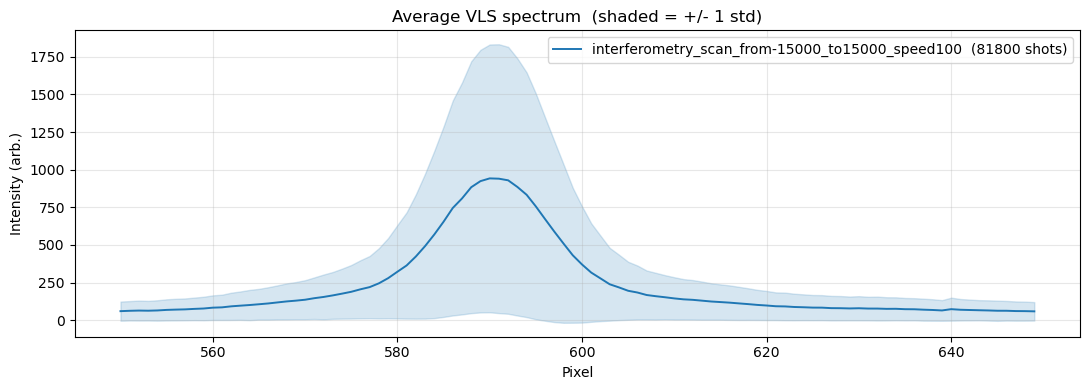

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
for label, data in runs.items():
    flat = data.vls.reshape(-1, data.vls.shape[-1])
    mean_spec = np.nanmean(flat, axis=0)
    std_spec  = np.nanstd(flat,  axis=0)
    line, = ax.plot(data.vls_pixels, mean_spec, lw=1.4,
                    label=f"{label}  ({flat.shape[0]} shots)")
    ax.fill_between(data.vls_pixels,
                    mean_spec - std_spec, mean_spec + std_spec,
                    color=line.get_color(), alpha=0.18)
ax.set_xlabel("Pixel")
ax.set_ylabel("Intensity (arb.)")
ax.set_title("Average VLS spectrum  (shaded = +/- 1 std)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Mean spectrum vs bunch index

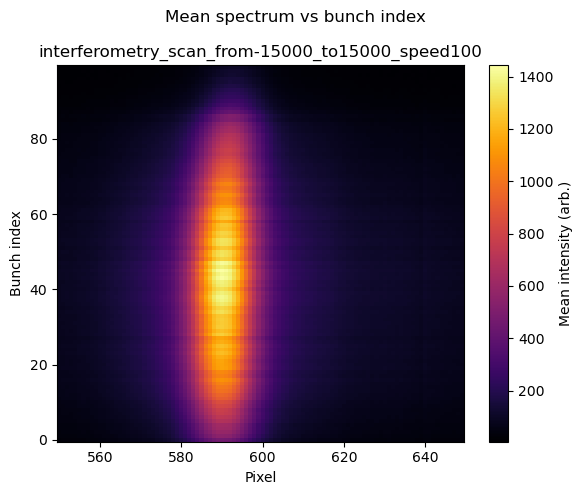

In [14]:
fig, axes = plt.subplots(1, len(runs),
                         figsize=(6 * len(runs), 5),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (label, data) in zip(axes, runs.items()):
    mean_by_bunch = np.nanmean(data.vls, axis=0)
    norm = (mcolors.LogNorm(vmin=max(np.nanmin(mean_by_bunch), 1e-3),
                            vmax=np.nanmax(mean_by_bunch))
            if LOG_MAP else None)
    im = ax.pcolormesh(data.vls_pixels, np.arange(data.vls.shape[1]),
                       mean_by_bunch, cmap="inferno",
                       shading="auto", norm=norm)
    fig.colorbar(im, ax=ax, label="Mean intensity (arb.)")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Bunch index")
    ax.set_title(label)
fig.suptitle("Mean spectrum vs bunch index")
fig.tight_layout()
plt.show()

## Mean spectrum vs train index

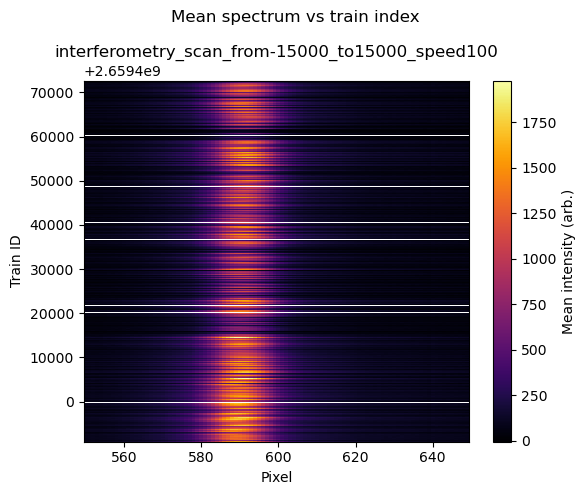

In [15]:
fig, axes = plt.subplots(1, len(runs),
                         figsize=(6 * len(runs), 5), sharex=True)
axes = np.atleast_1d(axes)
for ax, (label, data) in zip(axes, runs.items()):
    mean_by_train = np.nanmean(data.vls, axis=1)
    norm = (mcolors.LogNorm(vmin=max(np.nanmin(mean_by_train), 1e-3),
                            vmax=np.nanmax(mean_by_train))
            if LOG_MAP else None)
    im = ax.pcolormesh(data.vls_pixels, data.tID, mean_by_train,
                       cmap="inferno", shading="auto", norm=norm)
    fig.colorbar(im, ax=ax, label="Mean intensity (arb.)")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Train ID")
    ax.set_title(label)
fig.suptitle("Mean spectrum vs train index")
fig.tight_layout()
plt.show()

## Per-shot spectral moments

Per-shot sum / centre-of-mass / width on the cropped + baseline-
subtracted spectra. One row per file. Histograms are clipped to the
1-99 %ile so a handful of noise blow-ups don't dominate.

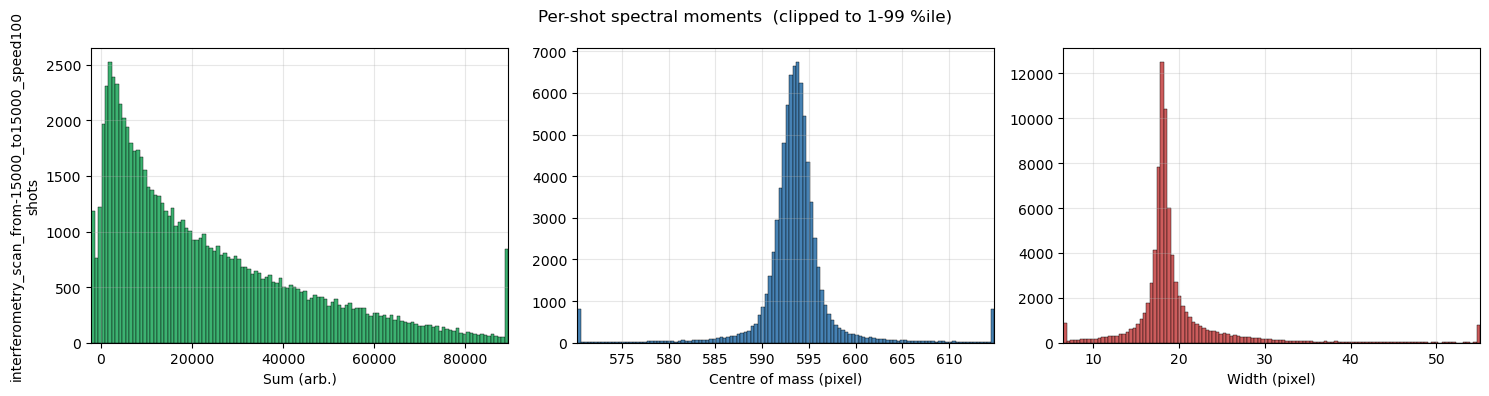

In [16]:
labels = ("Sum (arb.)", "Centre of mass (pixel)", "Width (pixel)")
colours = ("mediumseagreen", "steelblue", "indianred")

fig, axes = plt.subplots(len(runs), 3,
                         figsize=(15, 4 * len(runs)),
                         sharex="col")
axes = np.atleast_2d(axes)

for row, (label, data) in zip(axes, runs.items()):
    moments = (data.vls_sums, data.vls_coms, data.vls_widths)
    for ax, vals, lab, col in zip(row, moments, labels, colours):
        finite = vals.ravel()[np.isfinite(vals.ravel())]
        lo, hi = np.nanpercentile(finite, [1, 99])
        ax.hist(np.clip(finite, lo, hi), bins=120,
                color=col, edgecolor="black", linewidth=0.3)
        ax.set_xlabel(lab)
        ax.set_xlim(lo, hi)
        ax.grid(alpha=0.3)
    row[0].set_ylabel(f"{label}\nshots")

fig.suptitle("Per-shot spectral moments  (clipped to 1-99 %ile)")
fig.tight_layout()
plt.show()

## COM, width, and delay distributions: overlay

Direct overlay of the per-shot COM, width and delay (`z`) distributions
across files. Histograms are density-normalised with a shared 1-99
%ile clip per panel.

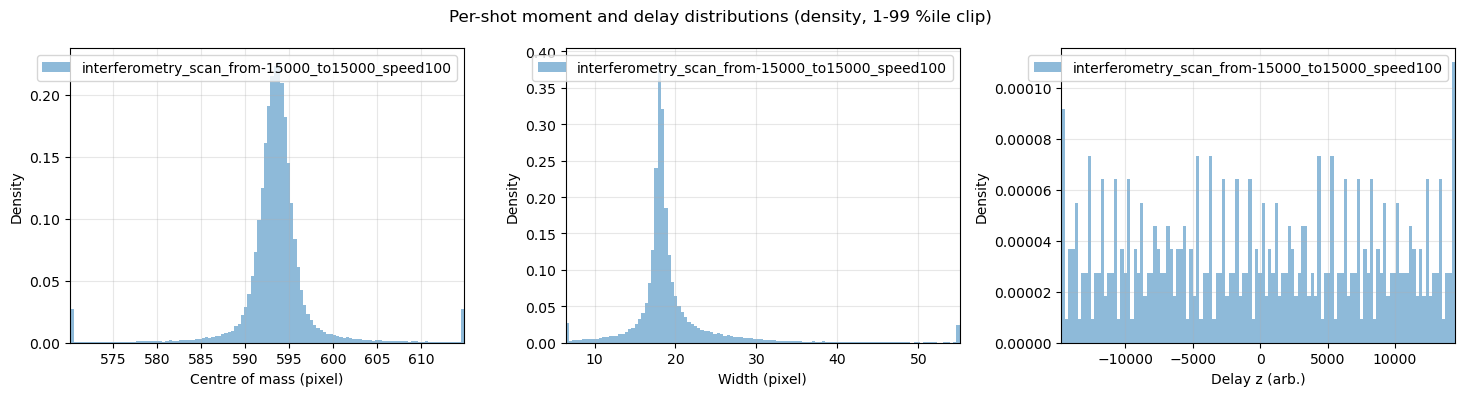

In [17]:
def _shared_clip(arrays, lo_pc=1, hi_pc=99):
    finite = np.concatenate([a.ravel()[np.isfinite(a.ravel())] for a in arrays])
    return tuple(np.nanpercentile(finite, [lo_pc, hi_pc]))


com_clip   = _shared_clip([d.vls_coms   for d in runs.values()])
width_clip = _shared_clip([d.vls_widths for d in runs.values()])
z_clip     = _shared_clip([d.z          for d in runs.values()])

fig, (ax_com, ax_w, ax_z) = plt.subplots(1, 3, figsize=(15, 4))
for label, data in runs.items():
    com = data.vls_coms.ravel();  com = com[np.isfinite(com)]
    w   = data.vls_widths.ravel(); w  = w[np.isfinite(w)]
    z   = data.z.ravel();         z   = z[np.isfinite(z)]
    ax_com.hist(np.clip(com, *com_clip),   bins=120, alpha=0.5,
                label=label, density=True)
    ax_w.hist(  np.clip(w,   *width_clip), bins=120, alpha=0.5,
                label=label, density=True)
    ax_z.hist(  np.clip(z,   *z_clip),     bins=120, alpha=0.5,
                label=label, density=True)

ax_com.set_xlabel("Centre of mass (pixel)"); ax_com.set_xlim(com_clip)
ax_w.set_xlabel("Width (pixel)");            ax_w.set_xlim(width_clip)
ax_z.set_xlabel("Delay z (arb.)");           ax_z.set_xlim(z_clip)
for ax in (ax_com, ax_w, ax_z):
    ax.set_ylabel("Density"); ax.grid(alpha=0.3); ax.legend()

fig.suptitle("Per-shot moment and delay distributions (density, 1-99 %ile clip)")
fig.tight_layout()
plt.show()

## GMD vs per-shot VLS sum

One panel per file. White error bars show the GMD-percentile-binned
mean +/- std; dashed line is the OLS linear fit over all shots.

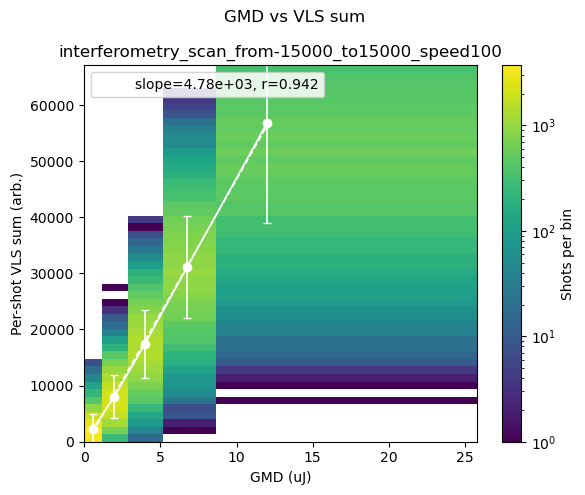

In [18]:
fig, axes = plt.subplots(1, len(runs), figsize=(6 * len(runs), 5))
axes = np.atleast_1d(axes)
for ax, (label, data) in zip(axes, runs.items()):
    gmd = data.gmd.ravel()
    s   = data.vls_sums.ravel()
    ok  = np.isfinite(gmd) & np.isfinite(s)
    x, y = gmd[ok], s[ok]

    edges = (np.asarray(GMD_EDGES, dtype=float)
             if GMD_EDGES is not None
             else np.percentile(x, np.linspace(0, 100, N_GMD_BINS + 1)))
    _, bool_ar = arb_bool_ar(edges, x)
    my, sy, _ = bin_and_average(bool_ar, y)
    mx, _, _  = bin_and_average(bool_ar, x)

    slope, intercept = np.polyfit(x, y, 1)
    r = float(np.corrcoef(x, y)[0, 1])
    xline = np.linspace(mx.min(), mx.max(), 100)

    h = ax.hist2d(x, y,
                  bins=[edges, np.linspace(0, np.percentile(y, 95), 51)],
                  cmap="viridis", cmin=1, norm=mcolors.LogNorm())
    fig.colorbar(h[3], ax=ax, label="Shots per bin")
    ax.errorbar(mx, my, yerr=sy, fmt="o-", color="white",
                capsize=3, lw=1.2)
    ax.plot(xline, slope * xline + intercept,
            color="white", ls="--", lw=1.2,
            label=f"slope={slope:.3g}, r={r:.3f}")
    ax.set_xlabel("GMD (uJ)")
    ax.set_ylabel("Per-shot VLS sum (arb.)")
    ax.set_title(label)
    ax.legend(loc="upper left", framealpha=0.85)

fig.suptitle("GMD vs VLS sum")
fig.tight_layout()
plt.show()

## Average VLS spectrum per GMD bin

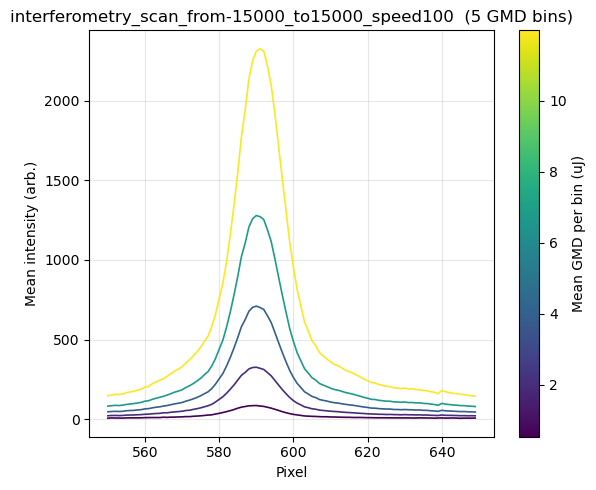

In [19]:
fig, axes = plt.subplots(1, len(runs),
                         figsize=(6 * len(runs), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, (label, data) in zip(axes, runs.items()):
    gmd = data.gmd.ravel()
    s   = data.vls_sums.ravel()
    ok  = np.isfinite(gmd) & np.isfinite(s)

    edges = (np.asarray(GMD_EDGES, dtype=float)
             if GMD_EDGES is not None
             else np.percentile(gmd[ok], np.linspace(0, 100, N_GMD_BINS + 1)))
    _, bool_ar = arb_bool_ar(edges, gmd[ok])
    mean_gmd, _, _ = bin_and_average(bool_ar, gmd[ok])

    specs = data.vls.reshape(-1, data.vls.shape[-1])[ok]
    mean_spec, _, _ = bin_and_average(bool_ar, specs)

    norm = Normalize(vmin=float(mean_gmd[0]), vmax=float(mean_gmd[-1]))
    for cent, spec in zip(mean_gmd, mean_spec):
        ax.plot(data.vls_pixels, spec,
                color=plt.cm.viridis(norm(cent)), lw=1.2)
    sm = ScalarMappable(norm=norm, cmap="viridis"); sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Mean GMD per bin (uJ)")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Mean intensity (arb.)")
    ax.set_title(f"{label}  ({len(mean_gmd)} GMD bins)")
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Average VLS spectrum per delay bin

Replaces the COM-binned figure from `vls_compare_runs`. Shots are
binned by SDU `z`; delay edges are pooled across files so the
colourbar is shared.

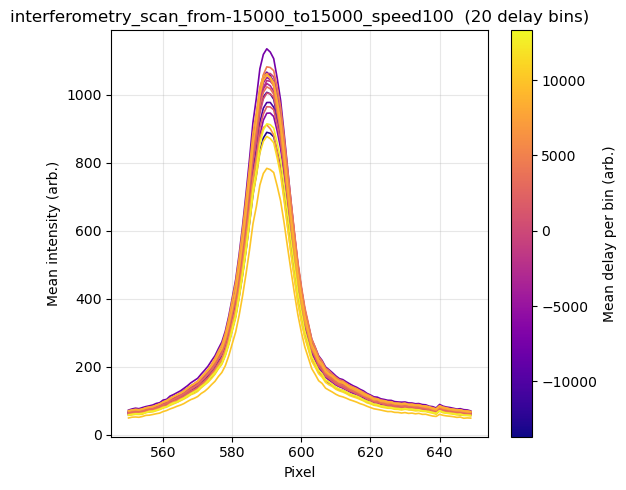

In [20]:
if Z_EDGES is None:
    z_pool = np.concatenate([d.z.ravel() for d in runs.values()])
    z_pool = z_pool[np.isfinite(z_pool)]
    z_edges_eff = np.percentile(z_pool, np.linspace(5, 95, N_Z_BINS + 1))
else:
    z_edges_eff = np.asarray(Z_EDGES, dtype=float)

norm_z = Normalize(vmin=float(z_edges_eff[0]),
                   vmax=float(z_edges_eff[-1]))

fig, axes = plt.subplots(1, len(runs),
                         figsize=(6 * len(runs), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, (label, data) in zip(axes, runs.items()):
    z   = data.z.ravel()
    s   = data.vls_sums.ravel()
    ok  = np.isfinite(z) & np.isfinite(s)

    _, bool_ar = arb_bool_ar(z_edges_eff, z[ok])
    mean_z, _, _ = bin_and_average(bool_ar, z[ok])

    specs = data.vls.reshape(-1, data.vls.shape[-1])[ok]
    mean_spec, _, _ = bin_and_average(bool_ar, specs)

    for cent, spec in zip(mean_z, mean_spec):
        ax.plot(data.vls_pixels, spec,
                color=plt.cm.plasma(norm_z(cent)), lw=1.2)
    sm = ScalarMappable(norm=norm_z, cmap="plasma"); sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Mean delay per bin (arb.)")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Mean intensity (arb.)")
    ax.set_title(f"{label}  ({len(mean_z)} delay bins)")
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Final comparison: GMD-normalised spectra per (delay bin x GMD bin)

For each (delay bin x GMD bin) pair compute

    sum(spectra) / sum(GMD)

via `bin_and_sum_ratio` — the energy-weighted average per the
CLAUDE.md convention.

One panel per GMD bin; within each panel, lines coloured by delay
bin centre and runs distinguished by line style (solid = first file,
dotted = second, etc.). GMD and delay edges are pooled across files
so the binning is shared.

In [ ]:
com_pool = np.concatenate([d.z.ravel() for d in runs.values()])
z_edges_final = (np.asarray(Z_EDGES, dtype=float)
                 if Z_EDGES is not None
                 else np.percentile(com_pool[np.isfinite(com_pool)],
                                    np.linspace(5, 95, N_Z_BINS_FINAL + 1)))

gmd_pool = np.concatenate([d.gmd.ravel() for d in runs.values()])
gmd_edges_final = (np.asarray(GMD_EDGES, dtype=float)
                   if GMD_EDGES is not None
                   else np.percentile(gmd_pool[np.isfinite(gmd_pool)],
                                      np.linspace(5, 95, N_GMD_BINS_FINAL + 1)))


def per_bin_normalised(data, z_edges, gmd_edges):
    """sum(spec)/sum(gmd) per (GMD bin, z bin), shape (n_gmd, n_z, n_pix)."""
    z     = data.z.ravel()
    gmd   = data.gmd.ravel()
    specs = data.vls.reshape(-1, data.vls.shape[-1])
    ok    = np.isfinite(z) & np.isfinite(gmd)
    z, gmd, specs = z[ok], gmd[ok], specs[ok]

    z_cents, z_mask     = arb_bool_ar(z_edges, z)
    gmd_cents, gmd_mask = arb_bool_ar(gmd_edges, gmd)

    n_z   = z_mask.shape[0]
    n_gmd = gmd_mask.shape[0]
    out = np.full((n_gmd, n_z, specs.shape[1]), np.nan)
    for g in range(n_gmd):
        joint = z_mask & gmd_mask[g][None, :]
        ratio, _ = bin_and_sum_ratio(joint, specs, gmd)
        out[g] = ratio
    return out, z_cents, gmd_cents


matrices = {label: per_bin_normalised(d, z_edges_final, gmd_edges_final)
            for label, d in runs.items()}
z_cents = next(iter(matrices.values()))[1]
gmd_cents = next(iter(matrices.values()))[2]
styles = ["-", ":", "--", "-."]
norm_z = Normalize(vmin=float(z_cents[0]), vmax=float(z_cents[-1]))
pixel_ax = next(iter(runs.values())).vls_pixels

for g in range(len(gmd_cents)):
    fig, ax = plt.subplots(figsize=(11, 5))
    for (label, (M, *_)), style in zip(matrices.items(), styles):
        for cent, spec in zip(z_cents, M[g]):
            ax.plot(pixel_ax, spec,
                    color=plt.cm.plasma(norm_z(cent)),
                    lw=1.2, ls=style)
        ax.plot([], [], color="black", lw=1.2, ls=style, label=label)
    sm = ScalarMappable(norm=norm_z, cmap="plasma"); sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Delay bin centre (arb.)")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("sum(spectra) / sum(GMD)")
    ax.set_title(f"GMD bin {g}: "
                 f"[{gmd_edges_final[g]:.2f}, {gmd_edges_final[g+1]:.2f}] uJ  "
                 f"(centre={gmd_cents[g]:.2f})")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

## Average |FFT| comparison per delay bin

Fourier-transform each per-shot spectrum along the pixel axis, then
average the magnitude across the shots that fall in each delay bin.
Interference fringes whose phase varies shot-to-shot survive in
`<|FFT|>` even when they wash out of the mean spectrum, and the
delay binning lets us watch how the fringe structure evolves with
the delay scan.

Three views of the same `(n_delay_bins, n_freqs)` matrix per file:

1. Line plot — one `<|FFT|>` curve per delay bin, coloured by bin
   centre.
2. 2D heatmap of `log10(<|FFT|>)` (frequency vs delay bin centre) so
   the structure can be read off as a map.
3. 2D heatmap of `<|FFT|> - <|FFT|>_mean_over_delay`, i.e. the
   delay-axis-mean subtracted so only the per-delay differences
   remain. Highlights how the fringe amplitude shifts across the
   scan.

Delay edges are pooled across files (same convention as the delay-
binned spectrum cell). `np.fft.rfft` keeps only positive frequencies;
unit is cycles / pixel. The DC bin is dropped from every view.

In [ ]:
# Reuse the pooled delay edges from the delay-binned cell. Override via
# Z_EDGES / N_Z_BINS in the params cell.
if Z_EDGES is None:
    z_pool = np.concatenate([d.z.ravel() for d in runs.values()])
    z_pool = z_pool[np.isfinite(z_pool)]
    z_edges_fft = np.percentile(z_pool, np.linspace(5, 95, N_Z_BINS + 1))
else:
    z_edges_fft = np.asarray(Z_EDGES, dtype=float)

norm_z = Normalize(vmin=float(z_edges_fft[0]),
                   vmax=float(z_edges_fft[-1]))


def compute_fft_matrix(data, z_edges):
    """Mean |FFT| of per-shot spectra, binned by delay (n_z, n_freqs)."""
    flat = data.vls.reshape(-1, data.vls.shape[-1])
    z_flat = data.z.ravel()
    ok = np.all(np.isfinite(flat), axis=1) & np.isfinite(z_flat)
    spec = flat[ok]
    zv   = z_flat[ok]
    n_pix = spec.shape[1]
    freqs = np.fft.rfftfreq(n_pix, d=1.0)

    z_cents, z_mask = arb_bool_ar(z_edges, zv)
    matrix = np.full((len(z_cents), freqs.size), np.nan, dtype=np.float64)
    for i, mask in enumerate(z_mask):
        if mask.any():
            matrix[i] = np.nanmean(
                np.abs(np.fft.rfft(spec[mask], axis=1)), axis=0,
            )
    return matrix, z_cents, freqs


fft_by_run = {label: compute_fft_matrix(d, z_edges_fft)
              for label, d in runs.items()}

# ------------------------------------------------------------------
# View 1: line plot, one |FFT| curve per delay bin.
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, len(runs),
                         figsize=(6 * len(runs), 5),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (label, (matrix, z_cents, freqs)) in zip(axes, fft_by_run.items()):
    for cent, row in zip(z_cents, matrix):
        if np.all(np.isnan(row)):
            continue
        ax.semilogy(freqs[1:], row[1:], lw=1.2,
                    color=plt.cm.plasma(norm_z(cent)))
    sm = ScalarMappable(norm=norm_z, cmap="plasma"); sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Delay bin centre (arb.)")
    ax.set_xlabel("Frequency (cycles / pixel)")
    ax.set_ylabel("<|FFT(spectrum)|>  (arb.)")
    ax.set_title(f"{label}  ({len(z_cents)} delay bins)")
    ax.grid(alpha=0.3, which="both")
fig.suptitle("Mean |FFT| per delay bin  (DC bin skipped)")
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# View 2: 2D heatmap of log10(<|FFT|>).
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, len(runs),
                         figsize=(6 * len(runs), 5),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (label, (matrix, z_cents, freqs)) in zip(axes, fft_by_run.items()):
    with np.errstate(divide="ignore", invalid="ignore"):
        matrix_log = np.log10(np.where(matrix > 0, matrix, np.nan))
    im = ax.pcolormesh(freqs[1:], z_cents, matrix_log[:, 1:],
                       cmap="viridis", shading="auto")
    fig.colorbar(im, ax=ax, label="log10(<|FFT|>)")
    ax.set_xlabel("Frequency (cycles / pixel)")
    ax.set_ylabel("Delay bin centre (arb.)")
    ax.set_title(label)
fig.suptitle("Mean |FFT| per delay bin  (2D map, DC skipped, log10)")
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# View 3: same map with the delay-axis mean subtracted, to highlight
# the per-delay differences.
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, len(runs),
                         figsize=(6 * len(runs), 5),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (label, (matrix, z_cents, freqs)) in zip(axes, fft_by_run.items()):
    mean_over_z = np.nanmean(matrix, axis=0)
    diff = matrix - mean_over_z[None, :]
    # Symmetric colour scale clipped to the 99 %ile of |diff|.
    vmax = float(np.nanpercentile(np.abs(diff[:, 1:]), 99))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0
    im = ax.pcolormesh(freqs[1:], z_cents, diff[:, 1:],
                       cmap="RdBu_r", shading="auto",
                       vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, label="<|FFT|> - <|FFT|>_mean_over_delay")
    ax.set_xlabel("Frequency (cycles / pixel)")
    ax.set_ylabel("Delay bin centre (arb.)")
    ax.set_title(label)
fig.suptitle("Mean |FFT| per delay bin, delay-mean subtracted  (DC skipped)")
fig.tight_layout()
plt.show()

## Random-shot animation per delay bin

Sample up to `N_SHOTS_PER_BIN` random shots from each delay bin, then
animate through them. Each frame is one shot per file; shots are
ordered by delay bin so colours sweep through the plasma colourbar
as the animation progresses. Each spectrum is normalised by its own
sum (turns the y-axis into a per-shot lineshape comparison rather
than an intensity comparison).

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

N_SHOTS_PER_BIN = 100
ANIM_INTERVAL_MS = 80          # frame delay
ANIM_SEED        = 0           # set to None for unseeded sampling

rng = np.random.default_rng(ANIM_SEED)

if Z_EDGES is None:
    z_pool = np.concatenate([d.z.ravel() for d in runs.values()])
    z_pool = z_pool[np.isfinite(z_pool)]
    z_edges_anim = np.percentile(z_pool, np.linspace(5, 95, N_Z_BINS + 1))
else:
    z_edges_anim = np.asarray(Z_EDGES, dtype=float)

norm_z = Normalize(vmin=float(z_edges_anim[0]),
                   vmax=float(z_edges_anim[-1]))


def build_shot_sequence(data, z_edges, n_per_bin, rng):
    """Sample up to n_per_bin random shots per delay bin.

    Returns
    -------
    spec : (n_total, n_pixels) array of per-shot spectra, normalised to
        unit sum.
    cents : (n_total,) array of delay bin centres for colouring/titles.
    """
    flat = data.vls.reshape(-1, data.vls.shape[-1])
    z_flat = data.z.ravel()
    ok = np.all(np.isfinite(flat), axis=1) & np.isfinite(z_flat)
    spec = flat[ok]
    zv   = z_flat[ok]

    z_cents, z_mask = arb_bool_ar(z_edges, zv)
    seq_spec, seq_cent = [], []
    for i, mask in enumerate(z_mask):
        idx = np.where(mask)[0]
        if idx.size == 0:
            continue
        n = min(n_per_bin, idx.size)
        chosen = rng.choice(idx, size=n, replace=False)
        seq_spec.append(spec[chosen])
        seq_cent.extend([z_cents[i]] * n)

    if not seq_spec:
        return np.zeros((0, spec.shape[1])), np.array([])
    s = np.concatenate(seq_spec, axis=0).astype(np.float64)
    # Per-shot sum normalisation. Zero / NaN sums -> drop those shots.
    s_sum = np.nansum(s, axis=1)
    good = np.isfinite(s_sum) & (s_sum != 0)
    s = s[good] / s_sum[good, None]
    cents = np.array(seq_cent)[good]
    return s, cents


seqs = {label: build_shot_sequence(d, z_edges_anim, N_SHOTS_PER_BIN, rng)
        for label, d in runs.items()}

n_frames = max((s.shape[0] for s, _ in seqs.values()), default=0)
if n_frames == 0:
    raise RuntimeError("No valid shots after normalisation; check the data.")

pixel_ax = next(iter(runs.values())).vls_pixels

# Shared y-limits from the 1-99 %ile of all sampled, normalised spectra.
all_spec = np.concatenate([s for s, _ in seqs.values() if s.size], axis=0)
y_lo, y_hi = np.nanpercentile(all_spec, [1, 99])
pad = 0.05 * (y_hi - y_lo)
y_lo, y_hi = y_lo - pad, y_hi + pad

fig, axes = plt.subplots(1, len(runs),
                         figsize=(6 * len(runs), 5), sharey=True)
axes = np.atleast_1d(axes)
lines, titles = [], []
for ax, (label, (spec, cents)) in zip(axes, seqs.items()):
    initial = spec[0] if spec.size else np.zeros_like(pixel_ax, dtype=float)
    line, = ax.plot(pixel_ax, initial, lw=1.2,
                    color=plt.cm.plasma(norm_z(cents[0])) if spec.size else "grey")
    ax.set_xlim(pixel_ax[0], pixel_ax[-1])
    ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Normalised intensity (sum = 1)")
    ax.grid(alpha=0.3)
    t = ax.set_title(f"{label}: shot 0/{spec.shape[0]}, z={cents[0]:.1f}"
                     if spec.size else f"{label}: no shots")
    lines.append(line)
    titles.append(t)

sm = ScalarMappable(norm=norm_z, cmap="plasma"); sm.set_array([])
fig.colorbar(sm, ax=axes.tolist(), label="Delay bin centre (arb.)")


def update(frame):
    artists = []
    for (label, (spec, cents)), line, title in zip(seqs.items(), lines, titles):
        if spec.size == 0:
            continue
        i = min(frame, spec.shape[0] - 1)
        line.set_ydata(spec[i])
        line.set_color(plt.cm.plasma(norm_z(cents[i])))
        title.set_text(f"{label}: shot {i + 1}/{spec.shape[0]}, z={cents[i]:.1f}")
        artists.extend([line, title])
    return artists


anim = FuncAnimation(fig, update, frames=n_frames,
                     interval=ANIM_INTERVAL_MS, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())